In [78]:
import numpy as np
import matplotlib.pyplot as plt
from tqdm import tqdm

In [79]:
def trial_wave_function_t01(beta, x):
    return np.exp(-1 * beta * x * x)


def local_energy_t01(beta, x):
    return beta + (0.5 - 2 * beta * beta) * x * x


def probability_density_t01(beta, x):
    return (trial_wave_function_t01(beta, x) * trial_wave_function_t01(beta, x)) / np.power(2 * beta / np.pi, 0.25)


def acceptance_ratio_t01(beta, x_current, x_next):
    return (trial_wave_function_t01(beta, x_next) * trial_wave_function_t01(beta, x_next) / (trial_wave_function_t01(beta, x_current) * trial_wave_function_t01(beta, x_current)))

In [80]:
rng = np.random.default_rng()

In [81]:
x_init = rng.random() * 2 - 1
step_size = 0.1
n_mc_steps = 10**5
n_therm_steps = 10**3

beta = 0.5

In [82]:
x_current = x_init
for i in tqdm(range(n_therm_steps)):
    x_next = x_current + (rng.random() * 2 * step_size - step_size)
    acceptance_ratio = acceptance_ratio_t01(beta, x_current, x_next)
    if (acceptance_ratio >= 1): # CHECK
        x_current = x_next

100%|██████████| 1000/1000 [00:00<00:00, 708018.91it/s]


In [83]:
total_energy = 0

for i in tqdm(range(n_mc_steps)):
    x_next = x_current + (rng.random() * 2 * step_size - step_size)
    acceptance_ratio = acceptance_ratio_t01(beta, x_current, x_next)
    if (acceptance_ratio >= 1): # CHECK
        x_current = x_next
        total_energy += local_energy_t01(beta, x_current) * probability_density_t01(beta, x_current)

total_energy = total_energy / n_mc_steps
print(total_energy)

  0%|          | 0/100000 [00:00<?, ?it/s]

100%|██████████| 100000/100000 [00:00<00:00, 761722.67it/s]

4.659673738398259e-05


In [84]:
print(total_energy)

4.659673738398259e-05


In [1]:
import numpy as np

raw_string = """
2.93515657e+04 1.26738689e+01 6.24048747e+00 4.19939266e+00
3.11588390e+00 2.53676513e+00 2.11719317e+00 1.80917708e+00
1.60059496e+00 1.42878470e+00 1.28933435e+00 1.18439731e+00
1.11023128e+00 1.02424274e+00 9.63748837e-01 9.14800697e-01
8.63211633e-01 8.20635479e-01 7.85251898e-01 7.51285201e-01
7.26205567e-01 7.00057032e-01 6.79115022e-01 6.58113253e-01
6.40924622e-01 6.24682093e-01 6.09642347e-01 5.98411340e-01
5.87770224e-01 5.76494450e-01 5.65563498e-01 5.57431568e-01
5.50161559e-01 5.43518491e-01 5.37510355e-01 5.32611953e-01
5.27406230e-01 5.22057948e-01 5.19320969e-01 5.15831937e-01
5.12255984e-01 5.09874016e-01 5.07492685e-01 5.05781994e-01
5.03919865e-01 5.02891203e-01 5.01701310e-01 5.00953796e-01
5.00365047e-01 5.00113077e-01 5.00000000e-01 5.00110754e-01
5.00425182e-01 5.00912705e-01 5.01561563e-01 5.02288015e-01
5.03354624e-01 5.04291106e-01 5.05489677e-01 5.06796953e-01
5.08657599e-01 5.09727066e-01 5.11510299e-01 5.13359463e-01
5.15325503e-01 5.17014036e-01 5.19412239e-01 5.21266265e-01
5.23580257e-01 5.26753523e-01 5.28804312e-01 5.30320252e-01
5.33430775e-01 5.36159638e-01 5.38998801e-01 5.41163848e-01
5.44266789e-01 5.47178223e-01 5.49900608e-01 5.52964925e-01
5.56388112e-01 5.59441365e-01 5.62538163e-01 5.65635881e-01
5.69046036e-01 5.71975685e-01 5.74880372e-01 5.78856440e-01
5.82160726e-01 5.85485938e-01 5.87813799e-01 5.92092378e-01
5.95917875e-01 5.99474596e-01 6.03114278e-01 6.06313099e-01
6.09651145e-01 6.14019410e-01 6.17835556e-01 6.21227562e-01
6.23874227e-01
"""

energy_arr = np.fromstring(raw_string, sep=' ')
beta_arr = np.linspace(0, 1, len(energy_arr))

In [10]:
beta_char = "\u03B2"
for i in range(len(energy_arr)):
    print(f"{beta_char} = {beta_arr[i]} ==> Energy = {energy_arr[i]}")

β = 0.0 ==> Energy = 29351.5657
β = 0.01 ==> Energy = 12.6738689
β = 0.02 ==> Energy = 6.24048747
β = 0.03 ==> Energy = 4.19939266
β = 0.04 ==> Energy = 3.1158839
β = 0.05 ==> Energy = 2.53676513
β = 0.06 ==> Energy = 2.11719317
β = 0.07 ==> Energy = 1.80917708
β = 0.08 ==> Energy = 1.60059496
β = 0.09 ==> Energy = 1.4287847
β = 0.1 ==> Energy = 1.28933435
β = 0.11 ==> Energy = 1.18439731
β = 0.12 ==> Energy = 1.11023128
β = 0.13 ==> Energy = 1.02424274
β = 0.14 ==> Energy = 0.963748837
β = 0.15 ==> Energy = 0.914800697
β = 0.16 ==> Energy = 0.863211633
β = 0.17 ==> Energy = 0.820635479
β = 0.18 ==> Energy = 0.785251898
β = 0.19 ==> Energy = 0.751285201
β = 0.2 ==> Energy = 0.726205567
β = 0.21 ==> Energy = 0.700057032
β = 0.22 ==> Energy = 0.679115022
β = 0.23 ==> Energy = 0.658113253
β = 0.24 ==> Energy = 0.640924622
β = 0.25 ==> Energy = 0.624682093
β = 0.26 ==> Energy = 0.609642347
β = 0.27 ==> Energy = 0.59841134
β = 0.28 ==> Energy = 0.587770224
β = 0.29 ==> Energy = 0.57649445
β

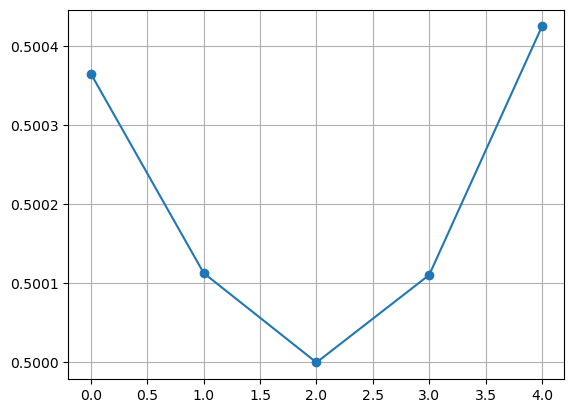

In [25]:
import matplotlib.pyplot as plt

plt.plot(energy_arr[48:53], marker='o')
plt.grid()
plt.show()